### Computing max average reward rates theoretically

Given an agent with a policy to gather $(k_1, \, k_2, \,k_3, \,...)$ rewards from an environment in which the reward function is

$$
    p(r=1 | R) = a e^{-R/\tau},
$$

where R is the sum of rewards within a patch, we would like to compute the expected return of the agent for a set of $\left(\tau_1, \tau_2, \tau_3\right)$ and a fixed $a$.

The expected reward for an environment with a single patch with reward curve parametrized by $\tau$ when the agent will gather $k$ rewards is

$$
    \mathbb{E}[r|k, \, \tau] = \frac{k}{n(k, \, \tau) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

where $n(k, \, \tau)$ is the expected number of stops required to harvest $k$ rewards.

In an environment with multiple patch types and a policy of stopping $n_i$ times for each, this becomes

$$
    \mathbb{E}[r|k, \, \tau] = \frac{\sum_i k_i}{ \sum_i n(k_i, \, \tau_i) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

We can first compute the probability of stopping n' times given the agent must collect k rewards and currently has collected R rewards,

$$
    p(n = n'| k, R),
$$

which obeys the recurrence relation

$$
    p(n = n'| k, R) = p(r=1| R) \, p(n = n'- 1| k-1, R+1) + p(r=0| R) \, p(n = n'- 1| k, R).
$$

We also know that if $k > n'$, then the associated probability is zero. If $k = 0$ and $n' > 0$, then the probability is also zero.

Once we have computed these probabilities, then

$$
    n(k, \, \tau) = \sum_{n'=k}^{\infty} p(n = n'| k, R) \, n'.
$$

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [275]:
def p_k_additional_rewards_in_n_sites_given_i_rewards(k, n, i, cache, a, tau):
    if n == 0:
        return 0
    elif k == 0:
        return 0
    else:
        if k > n:
            p = 0
        elif k == n:
            p = p_k_consecutive_rewarded_sites_given_i_rewards(k, i, a, tau)
        elif cache[k, n, i] != -1:
            p = cache[k, n, i]
        else:
            # n - k fails allowed
            p =  rewarded_given_i_rewards(i, a, tau) * p_k_additional_rewards_in_n_sites_given_i_rewards(k-1, n-1, i+1, cache, a, tau) \
            + unrewarded_given_i_rewards(i, a, tau) * p_k_additional_rewards_in_n_sites_given_i_rewards(k, n-1, i, cache, a, tau)
        cache[k, n, i] = p
        return p

def p_k_consecutive_rewarded_sites_given_i_rewards(k, i, a, tau):
    return np.prod([rewarded_given_i_rewards(i + r, a, tau) for r in np.arange(k)])

def rewarded_given_i_rewards(i, a, tau):
    return a * np.exp(-i/tau)

def unrewarded_given_i_rewards(i, a, tau):
    return 1 - rewarded_given_i_rewards(i, a, tau)

def expected_stops_given_tau_and_k_rewards(k, a, tau):
    exp_stops = 0
    max_stop_iter = 500
    cache = np.ones((k+1, max_stop_iter, k+1)) * -1
    probs = []
    for n in range(500):
        p_n_stops = p_k_additional_rewards_in_n_sites_given_i_rewards(k, n, 0, cache=cache, a=a, tau=tau)
        probs.append(p_n_stops)
        exp_stops += p_n_stops  * n
    exp_stops += (1 - np.sum(probs)) * max_stop_iter
    return exp_stops, probs

(0.0, 500.0)

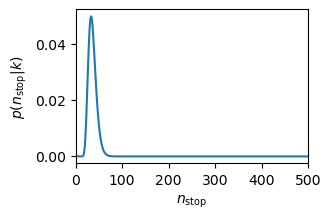

In [276]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=14, a=0.8, tau=10)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 500)

Given the agent must stop to collect $k$ rewards, here is an example of the probability dist. of stopping exactly $n$ times.

In [272]:
def expected_reward_rate_for_env_and_policy(taus, amps, k_rewards_by_tau, d_site_stop, d_site_run, d_intersite, interpatch):
    total_reward = np.sum(k_rewards_by_tau)
    denom = 0
    for tau, a, k in zip(taus, amps, k_rewards_by_tau):
        if k == 0:
            expected_n = 0
        else:
            expected_n, probs = expected_stops_given_tau_and_k_rewards(k=k, a=a, tau=tau)
        denom += (expected_n * (d_site_stop + d_intersite) + d_site_run)
    denom += len(taus) * interpatch
    return total_reward / denom


What is the theoretical maximum for the patch foraging task when

$$
    a_2 = a_3 = 0.8 \
$$
$$
    a_1 = 0 \
$$
$$
    \tau_2 = 10 \
$$
$$
    \tau_3 = 30
$$

In [273]:
max_policy = None
max_rate = 0
for k_2 in range(15):
    for k_3 in range(15):
        policy_rate = expected_reward_rate_for_env_and_policy(
            taus=[1e-8, 10, 30],
            amps=[0.8] * 3,
            k_rewards_by_tau=[0, k_2, k_3],
            d_site_stop=6,
            d_site_run=3,
            d_intersite=2.25,
            interpatch=5.28,
        )
        if policy_rate > max_rate:
            max_rate = policy_rate
            max_policy = (k_2, k_3)

print('Max policy', max_policy)
print('Max rate', max_rate)

Max policy (3, 9)
Max rate 0.07246861600161958


Model predicts a max reward rate of ~0.0725, which roughly agrees with the best performance simulated agents achieve.

#### Computing the average time spent running through intersite and interpatch intervals drawn from truncated exponential distributions

In [160]:
interreward_len_bounds = np.array([1.0, 6.0])
interreward_len_decay_rate = 0.8
interpatch_len_bounds = np.array([1.0, 12.0])
interpatch_len_decay_rate = 0.1

In [167]:
def sample_truncated_exp(bounds, decay_rate):
    """Sample from truncated exponential distribution
    
    Args:
        key: Random key
        bounds: [min_val, max_val] bounds for truncation
        decay_rate: Exponential decay rate parameter
    
    Returns:
        Sample from truncated exponential
    """
    min_val, max_val = bounds[0], bounds[1]
    
    # Sample from uniform [0, 1)
    u = np.random.rand()
    
    # Convert to truncated exponential using inverse CDF
    # F(x) = (1 - exp(-decay_rate * x)) / (1 - exp(-decay_rate * max_val))
    # for x in [0, max_val], then shift by min_val
    
    exp_max = np.exp(-decay_rate * (max_val - min_val))
    sample = -np.log(1 - u * (1 - exp_max)) / decay_rate
    
    return min_val + sample

In [277]:
mean_interward = np.mean([sample_truncated_exp(interreward_len_bounds, interreward_len_decay_rate) for i in range(1000)])
print('Mean interreward site distance:', mean_interward)

Mean interreward site distance 2.1505179655250277


In [278]:
mean_interpatch = np.mean([sample_truncated_exp(interpatch_len_bounds, interpatch_len_decay_rate) for i in range(1000)])
print('Mean interreward site distance:', mean_interpatch)

Mean interreward site distance: 5.604965735268499


#### What is the optimal reward rate for a series of environments where the reward parameters are drawn from a uniform distribution?

In [228]:
def find_max_policy_for_env(taus, amps):
    max_policy = None
    max_rate = 0
    for k_1 in range(10):
        for k_2 in range(10):
            for k_3 in range(10):
                policy_rate = expected_reward_rate_for_env_and_policy(
                    taus=taus,
                    amps=amps,
                    k_rewards_by_tau=(k_1, k_2, k_3),
                    d_site_stop=6,
                    d_site_run=3,
                    d_intersite=2.25,
                    interpatch=5.28,
                )
                if policy_rate > max_rate:
                    max_rate = policy_rate
                    max_policy = (k_1, k_2, k_3)
    
    # print('Max policy', max_policy)
    # print('Max rate', max_rate)
    return max_rate, max_policy
    

In [274]:
rates = np.zeros((50))
for i in range(50):
    taus = np.random.rand(3) * 15 + 1e-8 # draw taus independently from uniform distribution
    amps = np.ones((3))
    rate, policy = find_max_policy_for_env(taus, amps) # find max reward rate and policy for environment
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[13.61399213  2.34351341  2.68941866]
(6, 1, 2)
0.07946825861329575
[13.72157349 10.7734513  10.29621603]
(5, 4, 4)
0.08704280496156364
[3.94022313 2.153607   8.03175989]
(2, 2, 4)
0.07600129148176983
[10.39314331  8.64342069 11.95707666]
(4, 4, 5)
0.08559977882589477
[ 3.64692504 13.62903583  1.00788432]
(2, 6, 1)
0.08026637672312868
[13.01560918 13.53143134  7.58979661]
(5, 5, 3)
0.08683619542990809
[3.65325943 4.57423026 3.30296   ]
(2, 3, 2)
0.073960578244842
[ 2.62810199  6.30017584 12.59599887]
(2, 3, 6)
0.08127970746048584
[8.76871401 1.60643658 7.28146583]
(4, 1, 4)
0.07922944376826548
[4.95944372 2.34445643 2.92805288]
(3, 2, 2)
0.07270613367414835
[0.89986032 8.57142986 5.56429951]
(1, 4, 3)
0.07791283228788264
[ 6.66804422  8.01311448 14.60024278]
(3, 3, 6)
0.0850199123911493
[5.37259234 4.2577765  7.31889192]
(3, 2, 4)
0.07849082710296486
[ 8.80710613 13.76942364  9.01174754]
(4, 5, 4)
0.08580238927121447
[8.6578848  1.97334546 0.62686377]
(5, 1, 1)
0.07446389090960724
[ 0.

0.08064797285527998